# Model Preprocessing

This is the preprocessing applied in production.
- Train/validation/test split
- Scaling (StandardScaler, MinMaxScaler, RobustScaler)
- Normalisation (L2 norm)
- Full imputation
- Outlier handling
- Pipeline creation (sklearn Pipelines, SageMaker Pipelines)

Scaling all the column values for training, making sure to remove values which are invalid for scaling

In [6]:
import pandas as pd

df = pd.read_pickle('data/df_nba_games.pkl')

In [7]:
df.tail()

,season,date,home,team,team_opp,mp_5_diff,fg_5_diff,fga_5_diff,fg%_5_diff,3p_5_diff,...,blk%_max_10_diff,tov%_max_10_diff,usg%_max_10_diff,ortg_max_10_diff,drtg_max_10_diff,total_10_diff,home_10_diff,won_10_diff,days_rested_10_diff,won
25685,2025,2025-06-16,1,OKC,IND,0.0,3.4,3.2,0.0236,-0.8,...,-0.82,-10.51,4.08,46.4,-1.6,2.3,-0.1,0.1,0.1,True
25686,2025,2025-06-19,0,OKC,IND,0.0,0.4,1.4,-0.0014,-1.4,...,2.22,-11.74,4.07,48.5,-2.7,5.1,0.0,0.2,0.1,False
25687,2025,2025-06-19,1,IND,OKC,0.0,-0.4,-1.4,0.0014,1.4,...,-2.22,11.74,-4.07,-48.5,2.7,-5.1,0.0,-0.2,-0.1,True
25688,2025,2025-06-22,0,IND,OKC,0.0,1.0,2.8,-0.0034,2.2,...,-4.86,13.26,-1.80,-48.2,2.6,-4.1,0.1,-0.2,-0.1,False
25689,2025,2025-06-22,1,OKC,IND,0.0,-1.0,-2.8,0.0034,-2.2,...,4.86,-13.26,1.80,48.2,-2.6,4.1,-0.1,0.2,0.1,True


In [8]:
df.describe()

,season,home,mp_5_diff,fg_5_diff,fga_5_diff,fg%_5_diff,3p_5_diff,3pa_5_diff,3p%_5_diff,ft_5_diff,...,stl%_max_10_diff,blk%_max_10_diff,tov%_max_10_diff,usg%_max_10_diff,ortg_max_10_diff,drtg_max_10_diff,total_10_diff,home_10_diff,won_10_diff,days_rested_10_diff
count,12310.000000,12310.00000,12310.000000,12310.000000,12310.000000,12310.000000,1.231000e+04,1.231000e+04,12310.000000,1.231000e+04,...,12310.000000,1.231000e+04,1.231000e+04,12310.000000,12310.000000,12310.000000,12310.000000,1.231000e+04,1.231000e+04,12310.000000
mean,2023.046304,0.50000,0.000000,0.000000,0.000000,0.000000,-5.772077e-19,-2.886039e-19,0.000000,4.329058e-19,...,0.000000,-2.886039e-18,-5.772077e-18,0.000000,0.000000,0.000000,0.000000,-1.172453e-19,-3.156605e-19,0.000000
std,1.393193,0.50002,4.021961,3.909852,5.337282,0.039388,3.238555e+00,6.444099e+00,0.056459,4.036818e+00,...,2.285837,3.742627e+00,1.050774e+01,4.872562,21.555501,5.940073,7.591533,2.000867e-01,2.879751e-01,0.225059
min,2021.000000,0.00000,-20.000000,-14.000000,-21.200000,-0.144600,-1.200000e+01,-2.450000e+01,-0.200400,-1.640000e+01,...,-13.800000,-1.767000e+01,-4.876667e+01,-20.860000,-84.555556,-22.200000,-34.100000,-7.000000e-01,-1.000000e+00,-0.900000
25%,2022.000000,0.00000,0.000000,-2.600000,-3.600000,-0.026000,-2.200000e+00,-4.400000e+00,-0.037575,-2.800000e+00,...,-1.180000,-2.244444e+00,-7.140000e+00,-3.120000,-14.400000,-4.000000,-5.200000,-1.000000e-01,-2.000000e-01,-0.111111
50%,2023.000000,0.50000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,...,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
75%,2024.000000,1.00000,0.000000,2.600000,3.600000,0.026000,2.200000e+00,4.400000e+00,0.037575,2.800000e+00,...,1.180000,2.244444e+00,7.140000e+00,3.120000,14.400000,4.000000,5.200000,1.000000e-01,2.000000e-01,0.111111
max,2025.000000,1.00000,20.000000,14.000000,21.200000,0.144600,1.200000e+01,2.450000e+01,0.200400,1.640000e+01,...,13.800000,1.767000e+01,4.876667e+01,20.860000,84.555556,22.200000,34.100000,7.000000e-01,1.000000e+00,0.900000


In [9]:
from sklearn.preprocessing import MinMaxScaler

removed_columns = ["season", "date", "team", "team_opp", "won"]
selected_columns = df.columns[~df.columns.isin(removed_columns)]

scaler = MinMaxScaler()
df[selected_columns] = scaler.fit_transform(df[selected_columns])

In [10]:
df['won'] = df['won'].astype(int)

In [11]:
df.head()

,season,date,home,team,team_opp,mp_5_diff,fg_5_diff,fga_5_diff,fg%_5_diff,3p_5_diff,...,blk%_max_10_diff,tov%_max_10_diff,usg%_max_10_diff,ortg_max_10_diff,drtg_max_10_diff,total_10_diff,home_10_diff,won_10_diff,days_rested_10_diff,won
12810,2021,2020-12-25,1.0,MIL,GSW,0.65625,0.669643,0.541274,0.657331,0.750000,...,0.450009,0.505013,0.477895,0.488173,0.482482,0.570055,0.341270,0.555556,0.623457,1
12819,2021,2020-12-25,0.0,BRK,BOS,0.50000,0.357143,0.441038,0.399723,0.687500,...,0.551563,0.435748,0.465111,0.569645,0.269770,0.288205,0.579365,0.555556,0.685185,1
12817,2021,2020-12-25,0.0,LAC,DEN,0.50000,0.401786,0.547170,0.348721,0.531250,...,0.475791,0.731260,0.351390,0.438239,0.419920,0.517921,0.658730,0.500000,0.623457,1
12816,2021,2020-12-25,1.0,DEN,LAC,0.50000,0.598214,0.452830,0.651279,0.468750,...,0.524209,0.268740,0.648610,0.561761,0.580080,0.482079,0.341270,0.500000,0.376543,0
12815,2021,2020-12-25,0.0,DAL,LAL,0.50000,0.437500,0.541274,0.396266,0.604167,...,0.478306,0.272044,0.390274,0.361367,0.332332,0.576572,0.341270,0.388889,0.500000,0


In [12]:
df.to_pickle('data/df_nba_games_processed.pkl')

# Model Selection

| **Rank** | **Model Name** | **Short Description** | **Expected Performance** |
|---------|----------------|------------------------|---------------------------|
| **1** | XGBoost | Optimized gradient boosting; extremely strong on tabular data. | High — 65–75% accuracy. |
| **2** | LightGBM | Faster, leaf-wise boosting; excels on large datasets. | High — similar or better than XGBoost. |
| **3** | CatBoost | Gradient boosting built for categorical features. | High — excellent default performance. |
| **4** | Gradient Boosting | Sequential trees improving each step. | High — strong on structured data. |
| **5** | Random Forest | Ensemble of trees reducing overfitting. | High — 60–70% accuracy. |
| **6** | Logistic Regression | Linear classifier predicting probabilities. | Moderate — 55–65%. |
| **7** | MLP (Neural Network) | Fully connected neural network. | Moderate–High — depends on dataset size. |
| **8** | Support Vector Machine (SVM) | Margin-based classifier; strong but not scalable. | Moderate–High. |
| **9** | Decision Tree | Single tree with splitting rules. | Moderate — prone to overfitting. |
| **10** | K-Nearest Neighbour (KNN) | Instance-based classifier. | Low–Moderate — poor with many features. |
| **11** | Naive Bayes | Probabilistic classifier assuming feature independence. | Moderate — fast but simplistic. |
| **12** | LSTM | RNN for long-term sequences. | High for time series; lower for tabular. |
| **13** | GRU | Efficient LSTM variant. | High for time series; lower for tabular. |
| **14** | RNN | Standard recurrent neural network. | Moderate — struggles with long sequences. |
| **15** | Linear Regression | Predicts continuous values linearly. | Low–Moderate — poor for classification. |

- Baseline vs advanced models
- Cross-validation strategy

# Model Training

In [13]:
import pandas as pd

df = pd.read_pickle('df_nba_games_processed.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'df_nba_games_processed.pkl'

In [14]:
df.head()

,season,date,home,team,team_opp,mp_5_diff,fg_5_diff,fga_5_diff,fg%_5_diff,3p_5_diff,...,blk%_max_10_diff,tov%_max_10_diff,usg%_max_10_diff,ortg_max_10_diff,drtg_max_10_diff,total_10_diff,home_10_diff,won_10_diff,days_rested_10_diff,won
12810,2021,2020-12-25,1.0,MIL,GSW,0.65625,0.669643,0.541274,0.657331,0.750000,...,0.450009,0.505013,0.477895,0.488173,0.482482,0.570055,0.341270,0.555556,0.623457,1
12819,2021,2020-12-25,0.0,BRK,BOS,0.50000,0.357143,0.441038,0.399723,0.687500,...,0.551563,0.435748,0.465111,0.569645,0.269770,0.288205,0.579365,0.555556,0.685185,1
12817,2021,2020-12-25,0.0,LAC,DEN,0.50000,0.401786,0.547170,0.348721,0.531250,...,0.475791,0.731260,0.351390,0.438239,0.419920,0.517921,0.658730,0.500000,0.623457,1
12816,2021,2020-12-25,1.0,DEN,LAC,0.50000,0.598214,0.452830,0.651279,0.468750,...,0.524209,0.268740,0.648610,0.561761,0.580080,0.482079,0.341270,0.500000,0.376543,0
12815,2021,2020-12-25,0.0,DAL,LAL,0.50000,0.437500,0.541274,0.396266,0.604167,...,0.478306,0.272044,0.390274,0.361367,0.332332,0.576572,0.341270,0.388889,0.500000,0


In [15]:
removed_columns = ["season", "date", "team", "team_opp", "won"]
selected_columns = df.columns[~df.columns.isin(removed_columns)]

In [16]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## Baseline Model Performance

In [17]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(df[selected_columns], df["won"], test_size=0.3, random_state=42)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,      # you can adjust
        max_depth=6,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        verbose=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        objective='binary:logistic',
        eval_metric='auc',
        verbosity=1
    )
}

print("Model Accuracy")
for key in models.keys():
    model = models[key]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{key}: {accuracy_score(y_test, y_pred)}")

Model Accuracy
Logistic Regression: 0.6301110208502573
Random Forest: 0.6211751963173572
Gradient Boosting: 0.627944760357433
CatBoost: 0.6089899810452207
LightGBM: 0.6209044137557541
XGBoost: 0.6057405903059843


### Model Predictors

In [18]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import RidgeClassifier

from sklearn.metrics import accuracy_score

In [19]:
def backtest(data, model, predictors, start=1, step=1):
    all_predictions = []
    
    seasons = sorted(data["season"].unique())
    
    for i in range(start, len(seasons), step):
        season = seasons[i]
        
        train = data[data["season"] < season]
        test = data[data["season"] == season]
        
        model.fit(train[predictors], train["won"])
        
        preds = model.predict(test[predictors])
        preds = pd.Series(preds, index=test.index)
        
        combined = pd.concat([test["won"],preds], axis=1)
        combined.columns = ["actual", "prediction"]
        
        all_predictions.append(combined)
    return pd.concat(all_predictions)

In [20]:
def get_predictors(model,n_features=30,direction="forward"):
    split = TimeSeriesSplit(n_splits=3)

    print("Getting predictors...")
    sfs = SequentialFeatureSelector(model, n_features_to_select=n_features, direction=direction, cv=split)
    sfs.fit(df[selected_columns], df["won"])
    
    predictors = list(selected_columns[sfs.get_support()])
    print(f"{len(predictors)} predictors found")
    return predictors

In [21]:
list(df.columns[df.dtypes == "object"])

['team', 'team_opp']

In [22]:
removed_columns = list(df.columns[df.dtypes == "object"]) + ["season", "date", "won"]
selected_columns = df.columns[~df.columns.isin(removed_columns)]

In [23]:
rr = RidgeClassifier(alpha=1)
predictors = get_predictors(rr,n_features=50,direction="backward")
predictions = backtest(df, rr, predictors)
accuracy_score(predictions["actual"], predictions["prediction"])

Getting predictors...
50 predictors found


0.6303486529318542

In [24]:
predictors

['home',
 'mp_5_diff',
 'fga_5_diff',
 '3p%_5_diff',
 'orb_5_diff',
 'drb_5_diff',
 'orb%_5_diff',
 'drb%_5_diff',
 'ast%_5_diff',
 'blk%_5_diff',
 '3p_max_5_diff',
 '3pa_max_5_diff',
 'fta_max_5_diff',
 'trb_max_5_diff',
 'pf_max_5_diff',
 'pts_max_5_diff',
 '3par_max_5_diff',
 'trb%_max_5_diff',
 'stl%_max_5_diff',
 'usg%_max_5_diff',
 'ortg_max_5_diff',
 'fga_10_diff',
 'fta_10_diff',
 'orb_10_diff',
 'trb_10_diff',
 'ast_10_diff',
 'tov_10_diff',
 'ts%_10_diff',
 'orb%_10_diff',
 'trb%_10_diff',
 'stl%_10_diff',
 'blk%_10_diff',
 'drtg_10_diff',
 '3p_max_10_diff',
 '3p%_max_10_diff',
 'fta_max_10_diff',
 'ast_max_10_diff',
 'stl_max_10_diff',
 'pf_max_10_diff',
 'pts_max_10_diff',
 'gmsc_max_10_diff',
 'ts%_max_10_diff',
 'efg%_max_10_diff',
 '3par_max_10_diff',
 'ftr_max_10_diff',
 'drb%_max_10_diff',
 'trb%_max_10_diff',
 'tov%_max_10_diff',
 'usg%_max_10_diff',
 'drtg_max_10_diff']

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, mean_absolute_error, mean_squared_error, r2_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

## Fundamental Model Functions

In [26]:
# -----------------------------
# 1. Data Preparation
# -----------------------------
def prepare_train_test(df, feature_cols, target_col, test_size=0.3, random_state=42):
    X = df[feature_cols]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    return X_train, X_test, y_train, y_test

In [27]:
# -----------------------------
# 2. Model Training & Prediction
# -----------------------------
def train_and_predict(model, X_train, X_test, y_train):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return model, y_pred

In [28]:
# -----------------------------
# 3. Probability / Score Calculation
# -----------------------------
def get_model_scores(model, X_test):
    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_prob = MinMaxScaler().fit_transform(scores.reshape(-1,1)).ravel()
    return y_prob

In [29]:
# -----------------------------
# 4. Feature Importance
# -----------------------------
def compute_feature_importance(model, X_test, y_test, feature_cols, model_name="Model"):
    """
    Compute feature importance or coefficients for any model type.
    Handles:
      - Linear models (with coef_) — normalized 0–1
      - Logistic regression (adds Odds Ratios)
      - Tree-based models (with feature_importances_)
      - Other models via normalized permutation importance
    """
    is_logistic = False

    # --- 1. Linear / Logistic Models ---
    if hasattr(model, "coef_"):
        coef = model.coef_
        # Handle both 1D and 2D arrays safely
        if coef.ndim > 1:
            coef = coef[0]

        importance_vals = np.abs(coef)
        # ✅ Normalize to 0–1 range (avoid divide-by-zero)
        importance_vals = (importance_vals - importance_vals.min()) / (importance_vals.max() - importance_vals.min() + 1e-9)

        feature_importance = pd.DataFrame({
            "Feature": feature_cols,
            "Coefficient": coef,
            "Importance": importance_vals
        }).sort_values(by="Importance", ascending=False)

        # Detect logistic regression automatically
        if hasattr(model, "predict_proba") and "logistic" in model.__class__.__name__.lower():
            is_logistic = True
            feature_importance["Odds Ratio"] = np.exp(coef)

    # --- 2. Tree-based Models ---
    elif hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        # Normalize to 0–1
        importances = importances / (importances.max() + 1e-9)
        feature_importance = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

    # --- 3. Fallback: Permutation Importance ---
    else:
        perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        importances = np.abs(perm.importances_mean)
        importances = (importances - importances.min()) / (importances.max() - importances.min() + 1e-9)  # normalize 0–1

        feature_importance = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

    return feature_importance, is_logistic

In [30]:
# -----------------------------
# 5. Metrics Calculation
# -----------------------------
def calculate_metrics(y_test, y_pred, y_prob=None, is_classification=True):
    metrics = {}
    if is_classification:
        metrics["accuracy"] = accuracy_score(y_test, y_pred)
        metrics["classification_report"] = classification_report(y_test, y_pred)
        print(metrics["classification_report"])
        if y_prob is not None:
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            metrics["fpr"] = fpr
            metrics["tpr"] = tpr
            metrics["auc"] = auc(fpr, tpr)
    else:
        metrics["MAE"] = mean_absolute_error(y_test, y_pred)
        metrics["MSE"] = mean_squared_error(y_test, y_pred)
        metrics["RMSE"] = np.sqrt(metrics["MSE"])
        metrics["R2"] = r2_score(y_test, y_pred)
    return metrics

In [31]:
# -----------------------------
# 6. Dynamic Plotting
# -----------------------------
def plot_dashboard(metrics, y_test, y_pred, y_prob, feature_importance, is_classification, is_logistic, model_name="Model"):
    plots = []

    if is_classification:
        plots.append("Confusion Matrix")
        plots.append("Feature Importance")
        if y_prob is not None:
            plots.append("ROC Curve")
            plots.append("Probability Histogram")
    else:
        plots.extend(["Predicted vs Actual", "Residuals", "Feature Importance"])

    n_plots = len(plots)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
    if n_rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, plot_name in enumerate(plots):
        ax = axes[i]

        if plot_name == "Confusion Matrix":
            ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                   display_labels=np.unique(y_test)).plot(ax=ax, colorbar=False)
            ax.set_title("Confusion Matrix")

        elif plot_name == "ROC Curve":
            ax.plot(metrics["fpr"], metrics["tpr"], color="red", label=f"AUC = {metrics['auc']:.2f}")
            ax.plot([0,1],[0,1],'--', color="gray")
            ax.set_title("ROC Curve")
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.legend()

        elif plot_name == "Feature Importance":
            names = feature_importance["Feature"]
            colors = ['orange' if idx < 3 else 'skyblue' for idx in range(len(names))]

            if is_logistic and "Odds Ratio" in feature_importance.columns:
                # Use Odds Ratios instead of generic importance
                values = feature_importance["Odds Ratio"]
                ax.barh(names, values, color=colors)
                ax.axvline(1, color="gray", linestyle="--", linewidth=1)
                ax.set_xscale("log")
                ax.set_xlabel("Odds Ratio (Exp(β)) [log scale]")
                ax.set_title("Odds Ratios by Feature")

                # Optional: label only top few features
                top_n = 5
                for idx, val in enumerate(values[:top_n]):
                    ax.text(val, idx, f"{val:.2f}", va='center', ha='left', fontsize=9, color="black")

            else:
                # Standard feature importance plot
                values = feature_importance["Importance"]
                ax.barh(names, values, color=colors)
                ax.set_xlabel("Normalized Importance (0–1)")
                ax.set_title("Feature Importance")
                for idx, val in enumerate(values):
                    fontweight = 'bold' if idx < 3 else 'normal'
                    ax.text(val + val*0.01, idx, f"{val:.2f}", va='center', fontweight=fontweight)

        elif plot_name == "Probability Histogram":
            ax.hist(y_prob[y_test==1], bins=20, alpha=0.6, label="Class 1", color="green")
            ax.hist(y_prob[y_test==0], bins=20, alpha=0.6, label="Class 0", color="red")
            ax.set_xlabel("Predicted Probability")
            ax.set_ylabel("Frequency")
            ax.legend()
            ax.set_title("Predicted Probability Distribution")

        elif plot_name == "Predicted vs Actual":
            ax.scatter(y_test, y_pred, alpha=0.6)
            ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
            ax.set_xlabel("Actual")
            ax.set_ylabel("Predicted")
            ax.set_title("Predicted vs Actual")

        elif plot_name == "Residuals":
            residuals = y_test - y_pred
            ax.hist(residuals, bins=20, color="skyblue")
            ax.set_xlabel("Residual")
            ax.set_ylabel("Frequency")
            ax.set_title("Residuals")

    # Turn off unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"{model_name} Evaluation Dashboard", fontsize=16, weight="bold")
    plt.show()

In [32]:
# -----------------------------
# 7. Main Dashboard Wrapper
# -----------------------------
def evaluation_dashboard(df, model, feature_cols, target_col, model_name="Model"):
    X_train, X_test, y_train, y_test = prepare_train_test(df, feature_cols, target_col)
    model, y_pred = train_and_predict(model, X_train, X_test, y_train)
    is_classification = hasattr(model, "predict_proba") or hasattr(model, "decision_function") \
                        or (y_train.nunique() <= 10 and pd.api.types.is_integer_dtype(y_train))
    y_prob = get_model_scores(model, X_test)
    feature_importance, is_logistic = compute_feature_importance(model, X_test, y_test, feature_cols, model_name)
    metrics = calculate_metrics(y_test, y_pred, y_prob, is_classification)
    plot_dashboard(metrics, y_test, y_pred, y_prob, feature_importance, is_classification, is_logistic, model_name)
    return model, feature_importance

In [33]:
import joblib
import os

def save_model(model, predictors, feature_importance=None, model_name="model", folder="saved_models"):
    """
    Save a trained scikit-learn model along with predictors and optional feature importance.

    Parameters
    ----------
    model : sklearn estimator
        Trained scikit-learn model
    predictors : list of str
        Exact feature names used for training the model
    feature_importance : pandas Series or dict, optional
        Feature importance for interpretation
    model_name : str
        Name of the file (without extension)
    folder : str
        Folder path to save the model
    """
    # Create folder if it doesn't exist
    os.makedirs(folder, exist_ok=True)

    # Full file path
    filepath = os.path.join(folder, f"{model_name}.pkl")

    # Prepare dictionary to save
    save_dict = {
        "model": model,
        "predictors": predictors
    }

    if feature_importance is not None:
        save_dict["feature_importance"] = feature_importance

    # Save using joblib
    joblib.dump(save_dict, filepath)

    print(f"Model saved to {filepath}")

### Logistic Regression
__Type__: Classification  
__For__: Binary outcomes (yes/no, win/loss)  
__Pros__: Interpretable, probabilistic output  
__Cons__: Assumes linearity seperability

Note: 1958; still used in finance, medicine, sports

              precision    recall  f1-score   support

           0       0.62      0.63      0.63      1821
           1       0.64      0.63      0.63      1872

    accuracy                           0.63      3693
   macro avg       0.63      0.63      0.63      3693
weighted avg       0.63      0.63      0.63      3693



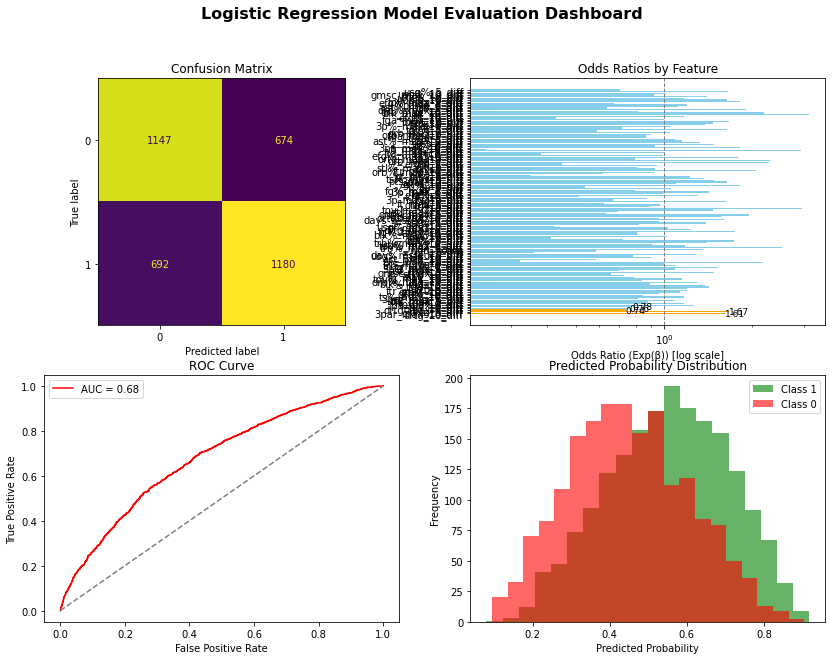

Model saved to saved_models\Logistic Regression Model.pkl


In [34]:
from sklearn.linear_model import LogisticRegression

predictors = selected_columns
model = LogisticRegression(max_iter=1000)
model, feature_importance = evaluation_dashboard(df, model, predictors, "won", "Logistic Regression Model")
save_model(model, predictors, feature_importance, model_name="Logistic Regression Model", folder="saved_models")

### Random Forest
__Type__: Both  
__For__: General-purpose baseline  
__Pros__: Reduces overfitting, robust, good accuracy  
__Cons__: Slower, less interpretable  

Note: 2001 (Breiman); got-to tabular model

              precision    recall  f1-score   support

           0       0.62      0.62      0.62      1821
           1       0.63      0.63      0.63      1872

    accuracy                           0.62      3693
   macro avg       0.62      0.62      0.62      3693
weighted avg       0.62      0.62      0.62      3693



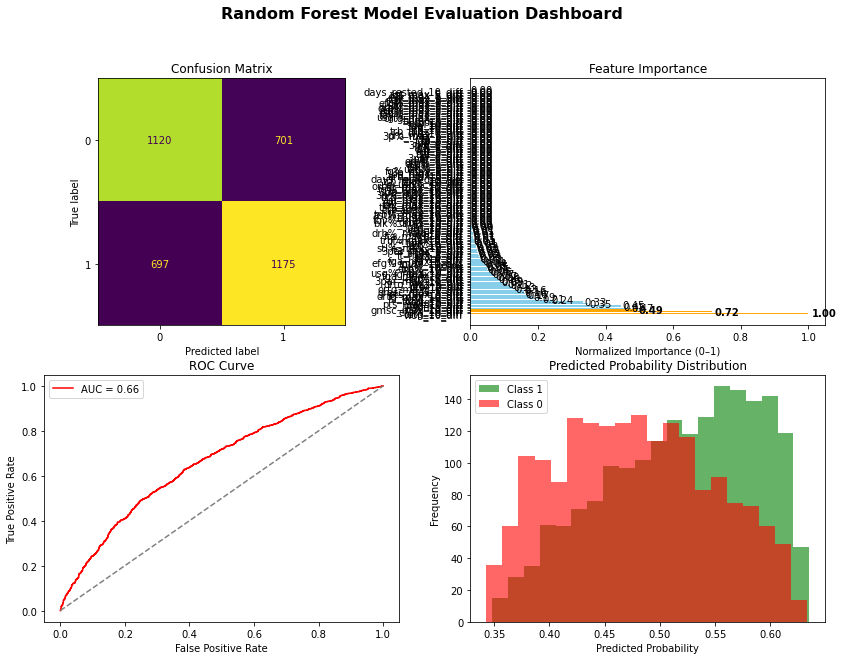

Model saved to saved_models\Random Forest Model.pkl


In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=2, random_state=0)
model, feature_importance = evaluation_dashboard(df, model, predictors, "won", "Random Forest Model")
save_model(model, predictors, feature_importance, model_name="Random Forest Model", folder="saved_models")

### Gradient Boosting (XGBoost, LightGBM)
__Type__: Both  
__For__: Tabular, structured data (competition winner)  
__Pros__: High accuracy, feature importance  
__Cons__: Harder to tune, longer training  

Note: 2014-2017; top Kaggle performers

              precision    recall  f1-score   support

           0       0.60      0.61      0.60      1821
           1       0.61      0.60      0.60      1872

    accuracy                           0.60      3693
   macro avg       0.60      0.60      0.60      3693
weighted avg       0.60      0.60      0.60      3693



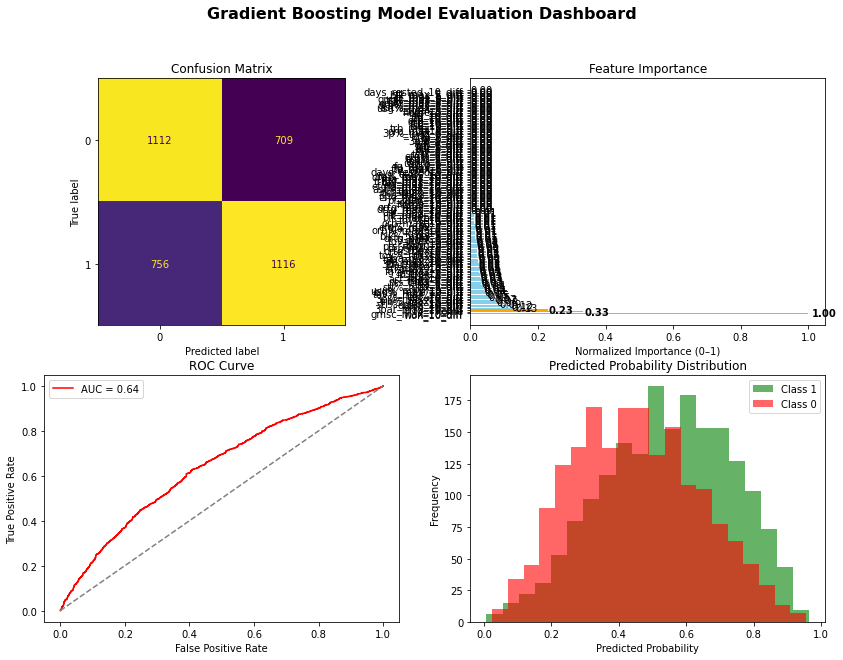

Model saved to saved_models\Gradient Boosting Model.pkl


In [36]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
    max_depth=1, random_state=0)
model, feature_importance = evaluation_dashboard(df, model, predictors, "won", "Gradient Boosting Model")
save_model(model, predictors, feature_importance, model_name="Gradient Boosting Model", folder="saved_models")

In [37]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


              precision    recall  f1-score   support

           0       0.61      0.63      0.62      1821
           1       0.63      0.61      0.62      1872

    accuracy                           0.62      3693
   macro avg       0.62      0.62      0.62      3693
weighted avg       0.62      0.62      0.62      3693



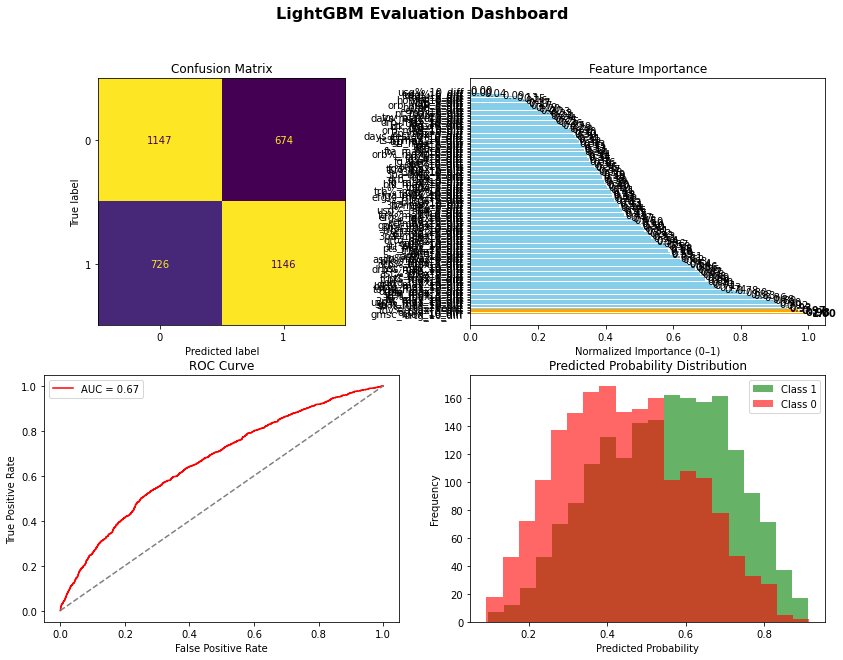

Model saved to saved_models\LightGBM.pkl


In [38]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model, feature_importance = evaluation_dashboard(df, model, predictors, "won", "LightGBM")
save_model(model, predictors, feature_importance, model_name="LightGBM", folder="saved_models")

In [39]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


C:\ProgramData\Anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:41:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.60      0.61      0.60      1821
           1       0.61      0.60      0.61      1872

    accuracy                           0.61      3693
   macro avg       0.61      0.61      0.61      3693
weighted avg       0.61      0.61      0.61      3693



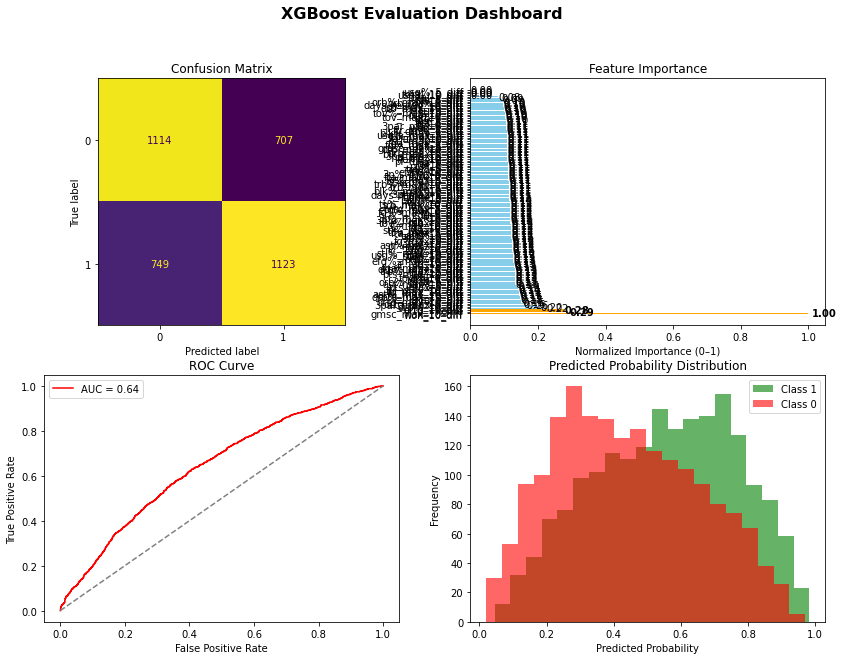

Model saved to saved_models\XGBoost.pkl


In [40]:
from xgboost import XGBClassifier

# Define XGBoost model
model = XGBClassifier(
    n_estimators=500,        # equivalent to iterations
    max_depth=6,             # equivalent to CatBoost depth
    learning_rate=0.05,
    objective='binary:logistic',  # for binary classification
    eval_metric='auc',            # same as CatBoost AUC
    use_label_encoder=False,
    verbosity=1                  # 0=silent, 1=warning/info
)

# Evaluate model using your existing evaluation dashboard
model, feature_importance = evaluation_dashboard(
    df, model, predictors, "won", "XGBoost"
)

# Save the trained model and feature importance
save_model(
    model,
    predictors,
    feature_importance,
    model_name="XGBoost",
    folder="saved_models"
)

## Model Evaluation

Ways to improve accuracy:
- Change number of games used to calculate rolling average
- You could search backwards through feature selection
- Change the number of seasons to look previously through
- Incorporate players dataset
- Look into finding team vs team performance in their last x matches

Players Dataset:
- Name
- stats
- performance in last 10 games
- performance against next team in last x games played against them